In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Point to the exact path inside your data/processed folder
df_nav = pd.read_csv("data/processed/02_nav_history.csv")
fund_master = pd.read_csv("data/processed/01_fund_master.csv")
df_bench = pd.read_csv("data/processed/10_benchmark_indices.csv") 

# Convert dates to standard format and sort chronologically
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date'])

df_bench['date'] = pd.to_datetime(df_bench['date'])
df_bench = df_bench.sort_values('date')

print("--- Step 1 Complete: Data loaded successfully from data/processed! ---")

--- Step 1 Complete: Data loaded successfully from data/processed! ---


In [4]:
# --- STEP 2: Compute Daily Returns & Validate (Task 1) ---

# 1. Calculate the daily percentage change in NAV for each mutual fund scheme
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# 2. Print a statistical summary to validate the distribution looks reasonable
print("--- Daily Returns Distribution Summary ---")
print(df_nav['daily_return'].describe())

# 3. Check for any unexpected extreme values
print("\nMax Daily Return:", df_nav['daily_return'].max())
print("Min Daily Return:", df_nav['daily_return'].min())

--- Daily Returns Distribution Summary ---
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Max Daily Return: 0.06471309359097144
Min Daily Return: -0.058102013949189124


In [5]:
# --- STEP 3: Compute Multi-Year CAGR (Task 2) ---

def get_cagr(group, years):
    days = int(years * 252) # Approximation of trading days per year
    if len(group) < days: 
        return np.nan
    end_val = group['nav'].iloc[-1]
    start_val = group['nav'].iloc[-days]
    return (end_val / start_val) ** (1 / years) - 1

# Apply CAGR calculation across all 40 funds
cagr_summary = df_nav.groupby('amfi_code').apply(lambda g: pd.Series({
    'cagr_1yr': get_cagr(g, 1),
    'cagr_3yr': get_cagr(g, 3),
    'cagr_5yr': get_cagr(g, 5)
}), include_groups=False).reset_index()

print("--- CAGR Performance Comparison Table (First 5 Funds) ---")
print(cagr_summary.head())

--- CAGR Performance Comparison Table (First 5 Funds) ---
   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016 -0.033055 -0.000316       NaN
1     100025  0.025018  0.046143       NaN
2     100033  0.477346  0.336292       NaN
3     101206  0.450939  0.325286       NaN
4     101207 -0.242421 -0.026965       NaN


In [6]:
# --- STEP 4: Compute Sharpe and Sortino Ratios (Tasks 3 & 4) ---

# Convert annual risk-free rate of 6.5% to a daily proxy
rf_daily = 0.065 / 252

# Calculate annualized risk-adjusted metrics across all funds
risk_metrics = df_nav.groupby('amfi_code').apply(lambda g: pd.Series({
    'sharpe_ratio': ((g['daily_return'].mean() - rf_daily) / g['daily_return'].std()) * np.sqrt(252),
    'sortino_ratio': ((g['daily_return'].mean() - rf_daily) / g[g['daily_return'] < 0]['daily_return'].std()) * np.sqrt(252)
}), include_groups=False).reset_index()

print("--- Risk-Adjusted Metrics (First 5 Funds) ---")
print(risk_metrics.head())

--- Risk-Adjusted Metrics (First 5 Funds) ---
   amfi_code  sharpe_ratio  sortino_ratio
0     100016     -0.201517      -0.351047
1     100025     -0.567095      -0.941821
2     100033      1.093699       1.829134
3     101206      1.027213       1.799563
4     101207      0.162661       0.276644


In [10]:
# --- STEP 5: Calculate Alpha, Beta, & Maximum Drawdown (Tasks 5 & 6) ---

# 1. Filter the benchmark data for Nifty 100 and calculate its daily returns
nifty_100 = df_bench[df_bench['index_name'].str.contains('100', na=False)].copy()
nifty_100 = nifty_100.sort_values('date')
nifty_100['nifty_100_return'] = nifty_100['close_value'].pct_change()

# 2. Merge your fund NAV data with the clean Nifty 100 returns on date
df_merged = pd.merge(df_nav, nifty_100[['date', 'nifty_100_return']], on='date', how='inner')

# 3. Function to compute stats for each fund group
def calculate_advanced_stats(g):
    clean_data = g.dropna(subset=['daily_return', 'nifty_100_return'])
    
    if len(clean_data) > 30:
        beta, intercept, _, _, _ = stats.linregress(clean_data['nifty_100_return'], clean_data['daily_return'])
        alpha = intercept * 252 # Annualized Alpha
    else:
        alpha, beta = np.nan, np.nan
        
    # Maximum Drawdown calculation
    rolling_max = g['nav'].cummax()
    drawdown = (g['nav'] / rolling_max) - 1
    max_dd = drawdown.min()
    
    return pd.Series({'alpha': alpha, 'beta': beta, 'max_drawdown': max_dd})

# Apply across all funds
advanced_metrics = df_merged.groupby('amfi_code').apply(calculate_advanced_stats, include_groups=False).reset_index()

print("--- Advanced Metrics (First 5 Funds) ---")
print(advanced_metrics.head())


--- Advanced Metrics (First 5 Funds) ---
   amfi_code     alpha      beta  max_drawdown
0     100016  0.037476 -0.058268     -0.247344
1     100025  0.042818  0.001158     -0.043083
2     100033  0.271954  0.005104     -0.162172
3     101206  0.213998  0.021086     -0.112916
4     101207  0.108971 -0.065289     -0.354469


In [8]:
print(df_bench.columns.tolist())

['date', 'index_name', 'close_value']


In [13]:
# --- STEP 6: Generate the Composite Scorecard (Task 7) ---

# 1. Combine all computed metrics together
scorecard = cagr_summary.merge(risk_metrics, on='amfi_code')
scorecard = scorecard.merge(advanced_metrics, on='amfi_code')

# 2. Join the expense_ratio_pct column from fund_master
scorecard = scorecard.merge(fund_master[['amfi_code', 'expense_ratio_pct']], on='amfi_code')

# 3. Create scoring ranks (Highest value is best, except for Expense Ratio & Max Drawdown where lower is better)
scorecard['rank_3yr'] = scorecard['cagr_3yr'].rank(ascending=False)
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['rank_alpha'] = scorecard['alpha'].rank(ascending=False)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=True) 
scorecard['rank_dd'] = scorecard['max_drawdown'].rank(ascending=False) 

# 4. Standardize ranks onto a comparative 0-100 scale
for col in ['rank_3yr', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_dd']:
    scorecard[col] = (scorecard[col].max() - scorecard[col]) / (scorecard[col].max() - scorecard[col].min()) * 100

# 5. Apply your exact blueprint percentage weights to get the final score
scorecard['final_score'] = (
    0.30 * scorecard['rank_3yr'] + 
    0.25 * scorecard['rank_sharpe'] + 
    0.20 * scorecard['rank_alpha'] + 
    0.15 * scorecard['rank_expense'] + 
    0.10 * scorecard['rank_dd']
)

# 6. Export required CSV deliverables directly to your project workspace
scorecard.to_csv('fund_scorecard.csv', index=False)
scorecard[['amfi_code', 'alpha', 'beta']].to_csv('alpha_beta.csv', index=False)

print("--- Step 6 Complete: fund_scorecard.csv and alpha_beta.csv successfully generated! ---")
print(scorecard[['amfi_code', 'final_score']].sort_values(by='final_score', ascending=False).head())

--- Step 6 Complete: fund_scorecard.csv and alpha_beta.csv successfully generated! ---
    amfi_code  final_score
34     148567    84.249084
25     120505    81.724942
2      100033    81.714952
30     120843    79.125874
24     120504    77.124542


In [12]:
# Check the exact column names of your fund master file
print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


--- Annualized Tracking Error vs Nifty 100 ---
Fund 148567: 18.97%
Fund 120505: 23.20%
Fund 100033: 22.87%
Fund 120843: 20.64%
Fund 120504: 19.16%


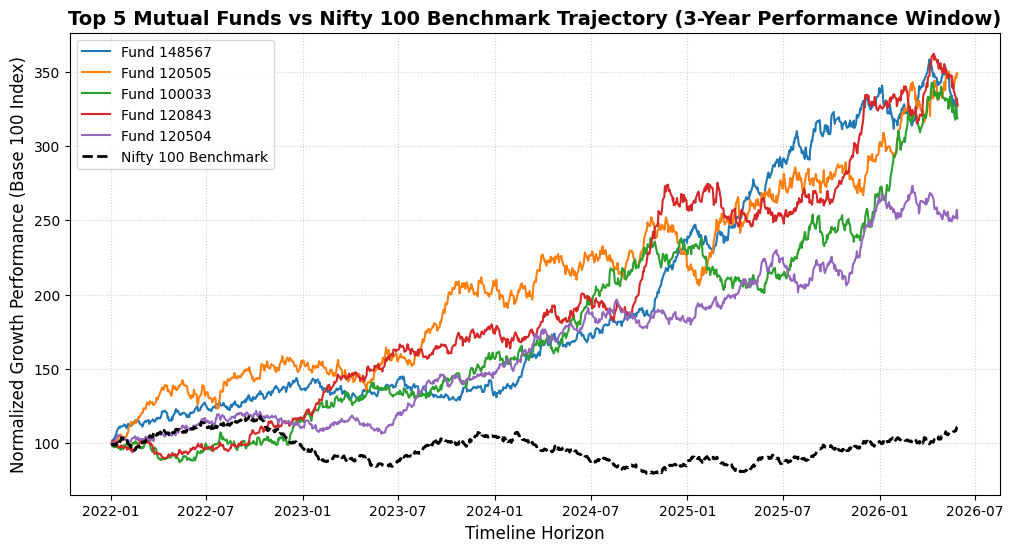


--- Step 7 Complete: benchmark_comparison_chart.png generated and saved! ---


In [14]:
# --- STEP 7: Benchmark Comparison Chart & Tracking Error (Task 8) ---

# 1. Extract the top 5 fund AMFI codes from your scorecard
top_5_funds = scorecard.sort_values(by='final_score', ascending=False).head(5)['amfi_code'].tolist()

# 2. Filter the benchmark data for tracking calculations (Nifty 100)
nifty_100 = df_bench[df_bench['index_name'].str.contains('100', na=False)].copy().sort_values('date')
nifty_100['nifty_100_return'] = nifty_100['close_value'].pct_change()

# 3. Plotting preparation
plt.figure(figsize=(12, 6))

print("--- Annualized Tracking Error vs Nifty 100 ---")

# 4. Loop through top 5 funds to calculate tracking error and plot performance trajectory
for fund in top_5_funds:
    fund_data = df_nav[df_nav['amfi_code'] == fund].copy().sort_values('date')
    
    # Calculate tracking error by aligning daily returns with benchmark returns
    merged_perf = pd.merge(fund_data[['date', 'daily_return', 'nav']], nifty_100[['date', 'nifty_100_return']], on='date', how='inner')
    merged_perf['return_difference'] = merged_perf['daily_return'] - merged_perf['nifty_100_return']
    tracking_error = merged_perf['return_difference'].std() * np.sqrt(252)
    
    print(f"Fund {fund}: {tracking_error:.2%}")
    
    # Normalize NAV data baseline to 100 for clear visual comparison
    if len(fund_data) > 0:
        plt.plot(fund_data['date'], (fund_data['nav'] / fund_data['nav'].iloc[0]) * 100, label=f"Fund {fund}")

# 5. Normalize and plot Nifty 100 benchmark line for direct comparison
if len(nifty_100) > 0:
    plt.plot(nifty_100['date'], (nifty_100['close_value'] / nifty_100['close_value'].iloc[0]) * 100, 
             label='Nifty 100 Benchmark', linestyle='--', color='black', linewidth=2)

# 6. Customize chart layouts and labels
plt.title('Top 5 Mutual Funds vs Nifty 100 Benchmark Trajectory (3-Year Performance Window)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Growth Performance (Base 100 Index)', fontsize=12)
plt.xlabel('Timeline Horizon', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

# 7. Save chart directly into your folder as requested by the blueprint deliverables
plt.savefig('benchmark_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- Step 7 Complete: benchmark_comparison_chart.png generated and saved! ---")